In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

2018년 10월 데이터를 활용. 결과는 11월 데이터

In [3]:
user_info = pd.read_csv('data/01.카드_회원정보_combined/201810_회원정보.csv')
credit_info = pd.read_csv('data/02.카드_신용정보_combined/201810_신용정보.csv')
approve_df = pd.read_csv('data/03.카드_승인매출정보_combined/201810_승인매출정보.csv')
card_info = pd.read_csv('data/04.카드_청구정보_combined/201810_청구정보.csv')
left_info = pd.read_csv('data/05.카드_잔액정보_combined/201810_잔액정보.csv')
channel_info = pd.read_csv('data/06.카드_채널정보_combined/201810_채널정보.csv')
marketing_df = pd.read_csv('data/07.카드_마케팅정보_combined/201810_마케팅정보.csv')
performance_info = pd.read_csv('data/08.카드_성과정보_combined/201810_성과정보.csv')

df = pd.read_csv('data/05.카드_잔액정보_combined/201811_잔액정보.csv')

In [4]:
df.shape

(3000000, 83)

In [5]:
# Read the list of target users
with open("artifacts/target_users.txt", "r") as f:
    target_users = [line.strip() for line in f.readlines()]

In [6]:
import json

with open('feature_lists.json', 'r') as f:
    feature_config = json.load(f)

In [7]:
feature_config['data_sources'].keys()

dict_keys(['승인매출정보', '회원정보', '신용정보', '청구정보', '잔액정보', '채널정보', '마케팅정보', '성과정보'])

In [8]:
key = feature_config['key']
key

'발급회원번호'

In [ ]:
user_info_x = user_info.loc[
    user_info[key].isin(target_users), 
                            feature_config['data_sources']['회원정보']['features']]

In [9]:
user_info_x = user_info.loc[user_info[key].isin(target_users), 
                            feature_config['data_sources']['회원정보']['features']]
credit_info_x = credit_info.loc[credit_info['발급회원번호'].isin(target_users), 
                              feature_config['data_sources']['신용정보']['features']]
approve_df_x = approve_df.loc[approve_df[key].isin(target_users), 
                              feature_config['data_sources']['승인매출정보']['features']]
left_info_x = left_info.loc[left_info['발급회원번호'].isin(target_users), 
                            feature_config['data_sources']['잔액정보']['features']]
channel_info_x = channel_info.loc[channel_info['발급회원번호'].isin(target_users), 
                                  feature_config['data_sources']['채널정보']['features']]
marketing_x = marketing_df.loc[marketing_df['발급회원번호'].isin(target_users), 
                                feature_config['data_sources']['마케팅정보']['features']]
performance_info_x = performance_info.loc[performance_info['발급회원번호'].isin(target_users), 
                                          feature_config['data_sources']['성과정보']['features']]

In [10]:
input_x = pd.concat([
    user_info_x,
    credit_info_x,
    approve_df_x,
    left_info_x,
    channel_info_x,
    marketing_x,
    performance_info_x], axis=1)

input_y = df.loc[df['발급회원번호'].isin(target_users), ['잔액_리볼빙일시불이월_B0M']]
input_y.columns = ['잔액_리볼빙일시불이월_target']

input = pd.concat([input_x, input_y], axis=1)

input.to_csv('artifacts/train_data.csv', index=False)

In [11]:
input.shape

(83403, 227)

In [12]:
input['잔액_리볼빙일시불이월_target'].describe()

count    8.340300e+04
mean     1.297853e+06
std      4.597873e+05
min      0.000000e+00
25%      9.937115e+05
50%      1.295272e+06
75%      1.593452e+06
max      3.800912e+06
Name: 잔액_리볼빙일시불이월_target, dtype: float64

<Axes: >

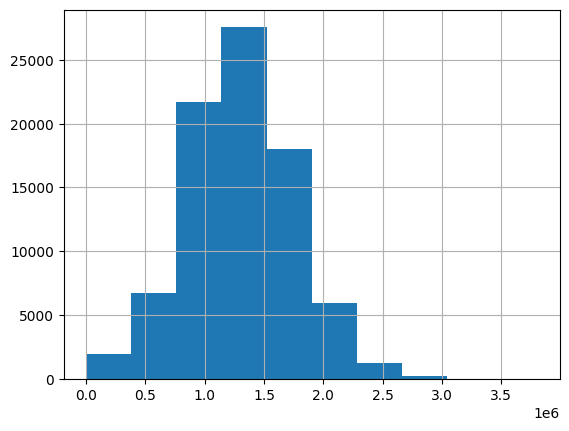

In [13]:
input['잔액_리볼빙일시불이월_target'].hist()

---
test data
---

2018년 11월 데이터를 활용. 결과는 12월 데이터

In [ ]:
user_info = pd.read_csv('data/01.카드_회원정보_combined/201811_회원정보.csv')
credit_info = pd.read_csv('data/02.카드_신용정보_combined/201811_신용정보.csv')
approve_df = pd.read_csv('data/03.카드_승인매출정보_combined/201811_승인매출정보.csv')
card_info = pd.read_csv('data/04.카드_청구정보_combined/201811_청구정보.csv')
left_info = pd.read_csv('data/05.카드_잔액정보_combined/201811_잔액정보.csv')
channel_info = pd.read_csv('data/06.카드_채널정보_combined/201811_채널정보.csv')
marketing_df = pd.read_csv('data/07.카드_마케팅정보_combined/201811_마케팅정보.csv')
performance_info = pd.read_csv('data/08.카드_성과정보_combined/201811_성과정보.csv')

df = pd.read_csv('data/05.카드_잔액정보_combined/201812_잔액정보.csv')

/var/folders/qb/pcn25z7557z6y3v_54hpjjxw0000gn/T/ipykernel_13197/786328427.py:3: DtypeWarning: Columns (207) have mixed types. Specify dtype option on import or set low_memory=False.
  approve_df = pd.read_csv('data/03.카드_승인매출정보_combined/201811_승인매출정보.csv')


In [12]:
# Read the list of target users
with open("artifacts/target_users.txt", "r") as f:
    target_users = [line.strip() for line in f.readlines()]

In [13]:
import json

with open('feature_lists.json', 'r') as f:
    feature_config = json.load(f)

In [14]:
feature_config['data_sources'].keys()

dict_keys(['승인매출정보', '회원정보', '신용정보', '청구정보', '잔액정보', '채널정보', '마케팅정보', '성과정보'])

In [15]:
key = feature_config['key']
key

'발급회원번호'

In [16]:
user_info_x = user_info.loc[user_info[key].isin(target_users), 
                            feature_config['data_sources']['회원정보']['features']]
credit_info_x = credit_info.loc[credit_info['발급회원번호'].isin(target_users), 
                              feature_config['data_sources']['신용정보']['features']]
approve_df_x = approve_df.loc[approve_df[key].isin(target_users), 
                              feature_config['data_sources']['승인매출정보']['features']]
left_info_x = left_info.loc[left_info['발급회원번호'].isin(target_users), 
                            feature_config['data_sources']['잔액정보']['features']]
channel_info_x = channel_info.loc[channel_info['발급회원번호'].isin(target_users), 
                                  feature_config['data_sources']['채널정보']['features']]
marketing_x = marketing_df.loc[marketing_df['발급회원번호'].isin(target_users), 
                                feature_config['data_sources']['마케팅정보']['features']]
performance_info_x = performance_info.loc[performance_info['발급회원번호'].isin(target_users), 
                                          feature_config['data_sources']['성과정보']['features']]

In [17]:
input_x = pd.concat([
    user_info_x,
    credit_info_x,
    approve_df_x,
    left_info_x,
    channel_info_x,
    marketing_x,
    performance_info_x], axis=1)

input_y = df.loc[df['발급회원번호'].isin(target_users), ['잔액_리볼빙일시불이월_B0M']]
input_y.columns = ['잔액_리볼빙일시불이월_target']

input = pd.concat([input_x, input_y], axis=1)

input.to_csv('artifacts/test_data.csv', index=False)

In [ ]:
input.shape

(83403, 227)

: 